# Case NPS Preditivo - Gráficos para a apresentação


## Pacotes

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## Leitura de Dados

In [2]:
#load dos dados
dados = pd.read_csv("https://raw.githubusercontent.com/braga0m/TechChallenge1/refs/heads/main/dados/dados_ecommerce_renomeado.csv")

In [3]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Cliente ID                             2500 non-null   int64  
 1   Idade do cliente                       2500 non-null   int64  
 2   Região do Cliente                      2500 non-null   object 
 3   Tempo de relacionamento com o cliente  2500 non-null   int64  
 4   Pedido ID                              2500 non-null   int64  
 5   Valor do pedido                        2500 non-null   float64
 6   Quantidade de itens                    2500 non-null   int64  
 7   Valor do desconto                      2500 non-null   float64
 8   Número de parcelas                     2500 non-null   int64  
 9   Tempo total da entrega                 2500 non-null   int64  
 10  Tempo de atraso da entrega             2500 non-null   int64  
 11  Valo

## Gráficos para a apresentação

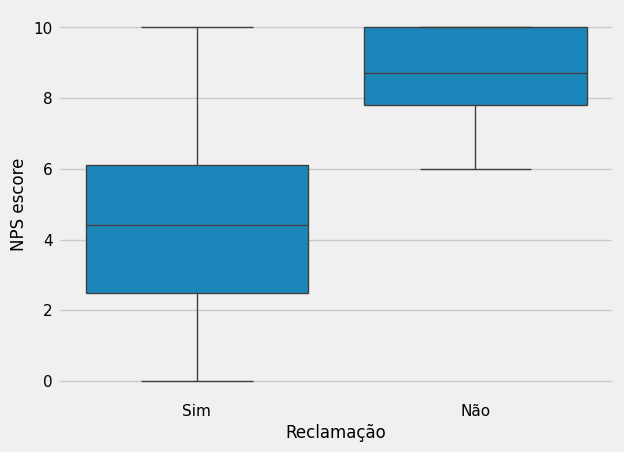

In [5]:
##
plt.style.use('fivethirtyeight') #estilos
sns.boxplot(data=dados,  x = "Reclamação (ajustado)", y="NPS escore")

plt.tick_params(axis='both', labelsize=11)
plt.xlabel("Reclamação", fontsize=12)
plt.ylabel("NPS escore", fontsize=12)

plt.show()

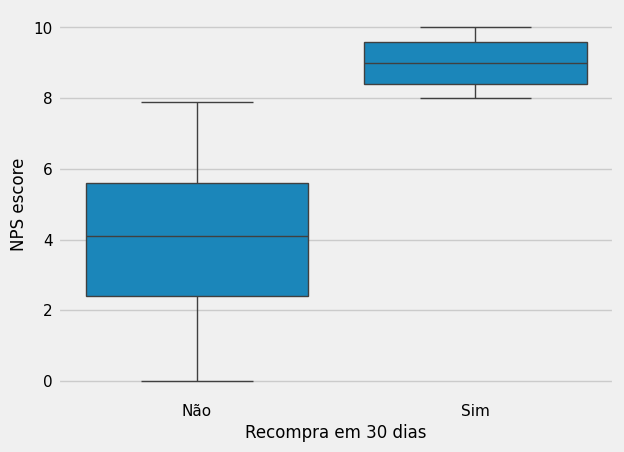

In [6]:
##
plt.style.use('fivethirtyeight') #estilos
sns.boxplot(data=dados,  x = "Recompra em 30 dias (ajustado)", y="NPS escore")

plt.tick_params(axis='both', labelsize=11)
plt.xlabel("Recompra em 30 dias", fontsize=12)
plt.ylabel("NPS escore", fontsize=12)

plt.show()

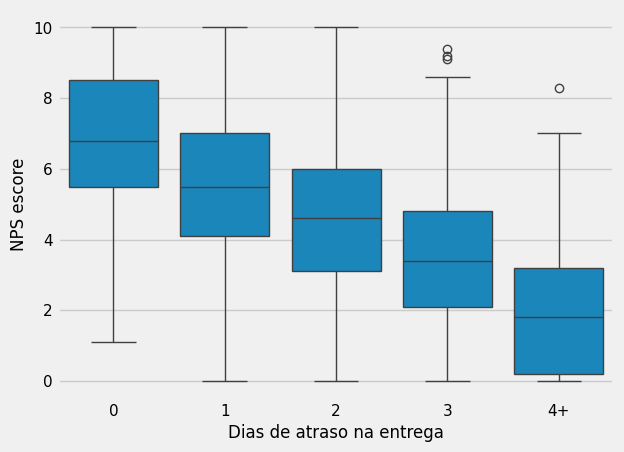

In [7]:

###definindo os levels da variável
dados["Dias de atraso na entrega"] = pd.Categorical(
    dados["Dias de atraso na entrega"],
    categories=["0", "1", "2", "3", "4+"],
    ordered=True
)


####
plt.style.use('fivethirtyeight') #estilos
sns.boxplot(data=dados,  x = "Dias de atraso na entrega", y="NPS escore")

plt.tick_params(axis='both', labelsize=11)
plt.xlabel("Dias de atraso na entrega", fontsize=12)
plt.ylabel("NPS escore", fontsize=12)

plt.show()

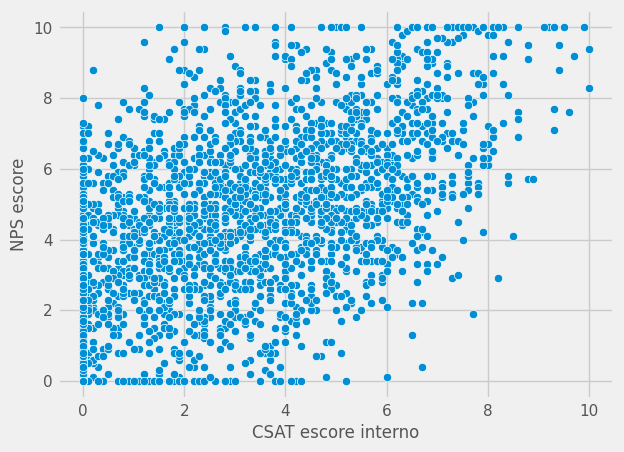

In [ ]:

plt.style.use('fivethirtyeight')
#plt.figure(figsize=(8, 5))


sns.scatterplot(
    data=dados,
    x= "CSAT escore interno",
    y= "NPS escore")

plt.tick_params(axis='both', labelsize=11)
plt.xlabel("CSAT escore interno", fontsize=12)
plt.ylabel("NPS escore", fontsize=12)

plt.show()

## Matriz de correlação (heatmap) entre as variáveis

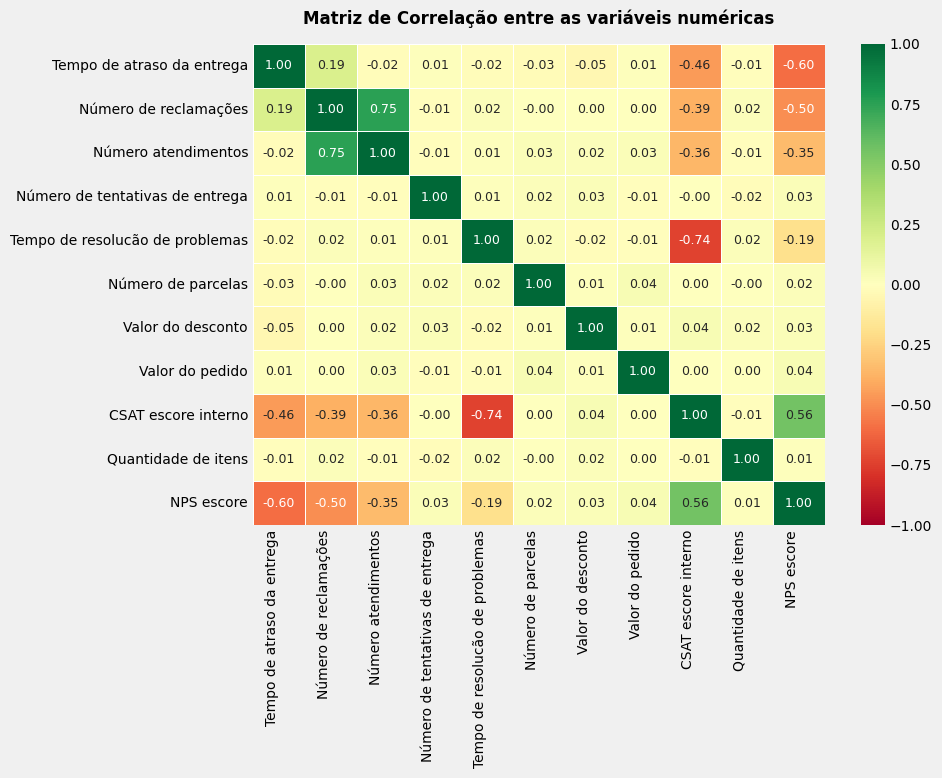

In [29]:
# ── Heatmap de correlação: variáveis operacionais vs. NPS ──────────────────────
# Pergunta: "Qual variável tem mais conexão com o NPS?" → Heatmap (correlação)
cols_operacionais = [
    'Tempo de atraso da entrega',
    'Número de reclamações',
    'Número atendimentos',
    'Número de tentativas de entrega',
    'Tempo de resolucão de problemas',
    'Número de parcelas',
    'Valor do desconto',
    'Valor do pedido',
    'CSAT escore interno',
    'Quantidade de itens',
    'NPS escore']

# ── Matriz de correlação das variáveis selecionadas ───────────────────────────
corr_matrix = dados[cols_operacionais].corr().round(2)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,          # exibe os valores dentro das células
    fmt='.2f',           # duas casas decimais
    cmap='RdYlGn',       # vermelho (negativo) → amarelo → verde (positivo)
    center=0,            # centro da paleta em zero
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    annot_kws={'size': 9}
)

# diminui a fonte dos valores da colorbar
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=10)

ax.set_title(
    "Matriz de Correlação entre as variáveis numéricas",
    fontsize=12, fontweight='bold', pad=14
)
plt.xticks(rotation=90, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
#plt.savefig('reports/heatmap_correlacao.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Top correlações com nps_score para referência numérica ────────────────────
#print("Correlação direta com NPS Score (ordenado):")
#corr_matrix['NPS escore'].drop('NPS escore').sort_values().round(3)